<a href="https://colab.research.google.com/github/mona0101/Final-year-project-2026/blob/main/RF_ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Training Implementation Summary**

* **Strategy: Transfer Learning**
    * **Backbone:** Utilizing pre-trained **ResNet-18** weights (ImageNet).
    * **Freeze Logic:** Backbone layers are frozen (`requires_grad=False`) to preserve general feature extraction.
    * **Training:** Only the custom **Linear Head (2 classes)** is being trained to adapt to RF-specific drone detection.

* **Data Engineering: Dimension Correction**
    * **The Issue:** HDF5 loader produces 5D tensors `[Batch, Sequence, Channels, H, W]`.
    * **The Fix:** Applied **Slicing `[:, 0]`** to remove the sequence dimension.
    * **Result:** Converts input to 4D `[Batch, 3, 112, 112]`, matching ResNet requirements.



In [ ]:
!pip install -q augly
!pip install -q librosa
!pip install torchinfo

import os
from google.colab import drive
if not os.path.exists('/content/drive'):
   drive.mount('/content/drive')
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import sys

# Fix for augly/torchaudio compatibility in Python 3.12 / Torchaudio 2.x
import torchaudio

# Define a mock class to replace the missing sox_effects module
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        # Most augly transforms just need the tensor returned if sox isn't handling it
        return tensor, sample_rate
# Inject the patch into sys.modules so augly can find it
if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 58.6 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026

Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 82 (delta 40), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 719.70 KiB | 10.28 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/Final-year-project-2026


In [ ]:
# Run this once before initializing the dataset
!cp "/content/drive/MyDrive/HDF5/Drone_Train.h5" "/content/Drone_Train.h5"
!cp "/content/drive/MyDrive/HDF5/Drone_Validation.h5" "/content/Drone_Validation.h5"
!cp "/content/drive/MyDrive/HDF5/Drone_Test.h5" "/content/Drone_Test.h5"

In [ ]:
import os
import h5py
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset
from PIL import Image
class DroneFusionDatasetH5(Dataset):
    def __init__(
        self,
        h5_path,
        transform=None,  # Dict containing your get_audio_transform, get_img_transform, etc.
        audio_feature_type='mfcc',
        modalities=['audio', 'video', 'rf'],
        is_training=True,
        n_mfcc=40,
        n_fft=2048,
        hop_length=512,
        n_mels=64,
        segment_length=0.25
    ):
        self.h5_path = h5_path
        self.audio_feature_type = audio_feature_type.lower()
        self.modalities = [m.lower() for m in modalities]
        self.is_training = is_training

        self.transform = transform or {}
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.segment_length = segment_length

        if not os.path.exists(self.h5_path):
            raise FileNotFoundError(f"HDF5 file not found at: {self.h5_path}")

        # Extract metadata
        with h5py.File(self.h5_path, 'r') as f:
            self.length = len(f['labels'])
            # Native SR from the H5 attributes (set during packing)
            self.native_sr = int(f.attrs.get('sr', 44100))

    def _extract_logmel(self, y, sr):
        # Exact logic from your original loader
        target_frames = int(np.ceil(self.segment_length / (138 / sr)))

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=138,
            n_mels=self.n_mels, power=2.0
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Z-score normalization
        log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

        if log_mel.shape[1] < target_frames:
            pad_width = target_frames - log_mel.shape[1]
            log_mel = np.pad(log_mel, ((0,0),(0,pad_width)), mode='constant')
        else:
            log_mel = log_mel[:, :target_frames]

        return torch.from_numpy(log_mel).unsqueeze(0).float()

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open inside getitem for DataLoader worker safety
        with h5py.File(self.h5_path, 'r') as f:
            # 1. Label
            label = torch.tensor(f['labels'][idx], dtype=torch.long)

            # 2. Audio Processing
            audio_tensor = torch.empty(0)
            if 'audio' in self.modalities:
                waveform = f['audio'][idx].astype(np.float32)
                sr = self.native_sr

                # Apply your custom get_audio_transform (augly/logmel_augment)
                if 'audio' in self.transform:
                    waveform, sr = self.transform['audio'](waveform, sr)

                if self.audio_feature_type == 'logmel':
                    max_val = np.max(np.abs(waveform))
                    if max_val > 0: waveform /= max_val
                    audio_tensor = self._extract_logmel(waveform, sr)
                else:
                    # MFCC "Diff Sampling" [::3]
                    waveform_sub = np.asfortranarray(waveform[::3])
                    mfcc = librosa.feature.mfcc(
                        y=waveform_sub, sr=sr, n_mfcc=self.n_mfcc,
                        n_fft=self.n_fft, hop_length=self.hop_length
                    )
                    pad_width = max(0, self.n_mfcc - mfcc.shape[1])
                    if pad_width > 0:
                        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
                    audio_tensor = torch.from_numpy(mfcc).float().unsqueeze(0)

            # 3. Video Processing (Using your get_img_transform)
            video_tensor = torch.empty(0)
            if 'video' in self.modalities:
                video_data = f['video'][idx]
                v_trans = self.transform.get('video')
                if v_trans:
                    # Logic: uint8 -> PIL -> your Compose (ToTensor + Augments + Normalize)
                    v_frames = [v_trans(Image.fromarray(video_data[i])) for i in range(len(video_data))]
                    video_tensor = torch.stack(v_frames)

            # 4. RF Processing (Using your get_rf_transform)
            rf_tensor = torch.empty(0)
            if 'rf' in self.modalities:
                rf_data = f['rf'][idx]
                rf_trans = self.transform.get('rf')
                if rf_trans:
                    # Logic: uint8 -> PIL -> your Compose (Resize + ToTensor + rf_aug + Normalize)
                    rf_frames = [rf_trans(Image.fromarray(rf_data[i])) for i in range(len(rf_data))]
                    rf_tensor = torch.stack(rf_frames)

        return audio_tensor, video_tensor, rf_tensor, label

In [ ]:

# --- 2. Configuration Class ---
from torch.utils.data import DataLoader
class Args:
    dataset_dir = '/content/'
    batch_size = 32
    feature_type = 'mfcc'  # Change to 'logmel' to update parameters below

    # Dynamic parameter selection based on original loader requirements
    n_mfcc = 40
    n_mels = 64 if feature_type == 'logmel' else 40

    num_workers = 2
    pin_memory = True
    modalities = ['rf']
    crop_size = 112

args = Args()

# --- 3. Setup Transforms ---
from augmentation import get_audio_transform, get_img_transform, get_rf_transform

train_transform = {
    'audio': get_audio_transform(args, is_training=True, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=True, augment=False),
    'rf': get_rf_transform(args, is_training=True, augment=True)
}

val_transform = {
    'audio': get_audio_transform(args, is_training=False, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=False, augment=False),
    'rf': get_rf_transform(args, is_training=False, augment=False)
}

# --- 4. Initialize Datasets & Loaders ---
train_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Train.h5'),
    transform=train_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=True
)

val_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Validation.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)


test_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Test.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)


loaders = {
    'train': DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
    'val': DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory),
    'test': DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory)
}








# --- 5. Final Printing and Verification ---
print(f"--- Dataset Summary ---")
print(f"Train Samples: {len(train_dataset)} | Batches: {len(loaders['train'])}")
print(f"Val Samples:   {len(val_dataset)} | Batches: {len(loaders['val'])}")
print(f"Val Samples:   {len(test_dataset)} | Batches: {len(loaders['test'])}\n")
print(f"--- Input Shape Verification ---")
try:
    audio_b, video_b, rf_b, label_b = next(iter(loaders['train']))
    print(f"Audio Shape: {audio_b.shape}")
    print(f"Video Shape: {video_b.shape}")
    print(f"RF Shape:    {rf_b.shape}")
    print(f"Label Shape: {label_b.shape}")
except Exception as e:
    print(f"Error during verification: {e}")

--- Dataset Summary ---
Train Samples: 8480 | Batches: 265
Val Samples:   1280 | Batches: 40
Val Samples:   1320 | Batches: 42

--- Input Shape Verification ---
Audio Shape: torch.Size([32, 0])
Video Shape: torch.Size([32, 0])
RF Shape:    torch.Size([32, 1, 3, 112, 112])
Label Shape: torch.Size([32])


#These are the functions I always use for plotting, training, and testing. Feel free to replace them if you prefer a different coding style.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
import copy
import time
import torchvision.models as models

def train_unimodal(model, dataloaders, device, criterion, optimizer, num_epochs=10, modal_num=2):
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for phase in ['train','val']:
            model.train() if phase=='train' else model.eval()
            running_loss, all_preds, all_labels = 0.0, [], []

            for batch in tqdm(dataloaders[phase], desc=f"{phase.upper()}", leave=False):

                # REMOVE TIME DIMENSION
                inputs = batch[modal_num][:,0].to(device).float()# lamar rf
                labels = batch[-1].to(device).long()

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase=='train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                preds = outputs.argmax(dim=1)
                all_preds.append(preds.detach())
                all_labels.append(labels.detach())

            # Metrics
            epoch_loss = running_loss / len(dataloaders[phase].dataset)

            y_true = torch.cat(all_labels).cpu().numpy()
            y_pred = torch.cat(all_preds).cpu().numpy()

            epoch_acc = accuracy_score(y_true, y_pred)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f"{phase.upper()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase=='val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
                print(f"Saved best model weights (Epoch {best_epoch} | Acc: {best_acc:.4f})")

    model.load_state_dict(best_model_wts)
    print(f"\nTraining complete. Best Epoch: {best_epoch} | Best Val Acc: {best_acc:.4f}")

    return model, history


# --------------------------
# Testing Function
# --------------------------
def test_unimodal(model, dataloader, device, modal_num=2, dataset_name="Dataset"):

    model.eval()
    all_preds, all_labels = [], []
    total_time, total_samples = 0, 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Testing {dataset_name}"):

            # REMOVE TIME DIMENSION
            inputs = batch[modal_num][:,0].to(device).float()
            labels = batch[-1].to(device).long()

            if device.type=='cuda':
                torch.cuda.synchronize()

            start = time.time()
            outputs = model(inputs)

            if device.type=='cuda':
                torch.cuda.synchronize()

            total_time += (time.time()-start)

            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

            total_samples += inputs.size(0)

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    avg_ms = (total_time / total_samples) * 1000
    fps = 1000 / avg_ms

    print(f"\n===== {dataset_name} Results =====")
    print(f"Accuracy: {accuracy:.4f} | F1 (macro): {f1.mean():.4f}")
    print(f"Latency: {avg_ms:.2f} ms/sample | FPS: {fps:.2f}")
    print("===============================\n")

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_ms': avg_ms,
        'fps': fps
    }

# --------------------------
#  Visualization Functions
# --------------------------
def plot_training_history(history):
    epochs = range(1,len(history['train_loss'])+1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'],  label='Val Loss')
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    class_names = ["No-Drone","Drone"]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_per_class_metrics_group(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    accuracy = [accuracy_score(y_true, y_pred)]*len(class_names)
    paired_colors = ['#1f78b4','#a6cee3','#b2df8a','#33a02c']
    x = np.arange(len(class_names))
    width = 0.2
    plt.figure(figsize=(8,5))
    plt.bar(x-1.5*width, precision, width, label="Precision", color=paired_colors[0])
    plt.bar(x-0.5*width, recall, width, label="Recall", color=paired_colors[1])
    plt.bar(x+0.5*width, f1, width, label="F1-score", color=paired_colors[2])
    plt.bar(x+1.5*width, accuracy, width, label="Accuracy", color=paired_colors[3])
    plt.xticks(x,class_names)
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.title(f"Per-Class Metrics ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    print(f"\n===== {dataset_name} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

torch.backends.cudnn.benchmark = True

Using device: cuda


In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# تجميد الباكبون (اختياري)
for param in model.parameters():
    param.requires_grad = False

# تغيير الطبقة الأخيرة لعدد الكلاسات (2 عندك)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(DEVICE)
from torchinfo import summary



summary(
    model,
    input_size=(32,3,112,112),
    col_names=["input_size","output_size","num_params","trainable"],
    row_settings=["var_names"]
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
ResNet (ResNet)                          [32, 3, 112, 112]         [32, 2]                   --                        Partial
├─Conv2d (conv1)                         [32, 3, 112, 112]         [32, 64, 56, 56]          (9,408)                   False
├─BatchNorm2d (bn1)                      [32, 64, 56, 56]          [32, 64, 56, 56]          (128)                     False
├─ReLU (relu)                            [32, 64, 56, 56]          [32, 64, 56, 56]          --                        --
├─MaxPool2d (maxpool)                    [32, 64, 56, 56]          [32, 64, 28, 28]          --                        --
├─Sequential (layer1)                    [32, 64, 28, 28]          [32, 64, 28, 28]          --                        False
│    └─BasicBlock (0)                    [32, 64, 28, 28]          [32, 64, 28, 28]          --                        False


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


# Plots & Reports





Epoch 1/10


TRAIN -> Loss: 0.2569 | Acc: 0.9015


VAL -> Loss: 0.1163 | Acc: 0.9656
Saved best model weights (Epoch 1 | Acc: 0.9656)

Epoch 2/10


TRAIN -> Loss: 0.1660 | Acc: 0.9416


VAL -> Loss: 0.0965 | Acc: 0.9688
Saved best model weights (Epoch 2 | Acc: 0.9688)

Epoch 3/10


...

VAL -> Loss: 0.0587 | Acc: 0.9789

Epoch 9/10


TRAIN -> Loss: 0.1304 | Acc: 0.9532


VAL -> Loss: 0.0492 | Acc: 0.9852
Saved best model weights (Epoch 9 | Acc: 0.9852)

Epoch 10/10


TRAIN -> Loss: 0.1364 | Acc: 0.9521


VAL -> Loss: 0.0659 | Acc: 0.9758

Training complete. Best Epoch: 9 | Best Val Acc: 0.9852


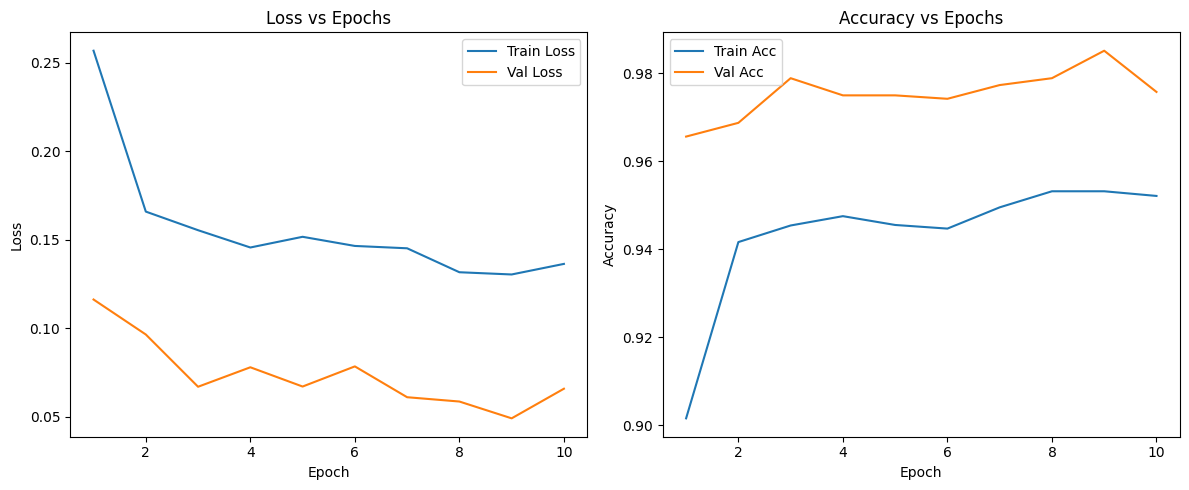

In [ ]:
num_epochs = 10
modal_num = 2  # RF modality (change to video=1 if using video input)


trained_model, history = train_unimodal(
    model,
    loaders,
    device=DEVICE,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    modal_num=modal_num
)

# Plots
plot_training_history(history)

Testing Train: 100%|██████████| 265/265 [00:25<00:00, 10.52it/s]



===== Train Results =====
Accuracy: 0.9604 | F1 (macro): 0.9599
Latency: 0.48 ms/sample | FPS: 2068.04



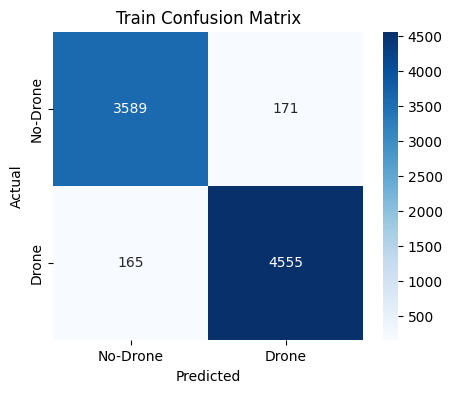

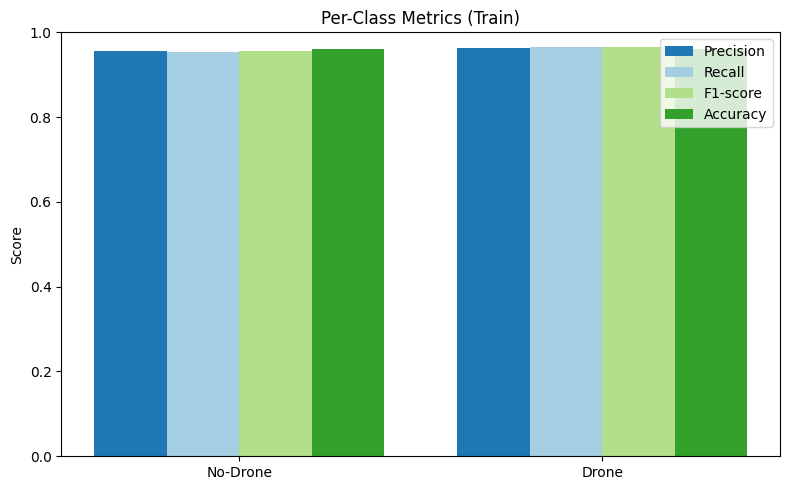


===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.9560    0.9545    0.9553      3760
       Drone     0.9638    0.9650    0.9644      4720

    accuracy                         0.9604      8480
   macro avg     0.9599    0.9598    0.9599      8480
weighted avg     0.9604    0.9604    0.9604      8480



In [ ]:
# Compute Train metrics (need to run the model in eval mode)
train_results = test_unimodal(trained_model, loaders['train'], DEVICE, modal_num=modal_num, dataset_name="Train")
# Train
plot_confusion_matrix(train_results['y_true'], train_results['y_pred'], title="Train Confusion Matrix")
plot_per_class_metrics_group(train_results['y_true'], train_results['y_pred'], dataset_name="Train")
print_classification_report(train_results['y_true'], train_results['y_pred'], dataset_name="Train")

Testing Validation: 100%|██████████| 40/40 [00:03<00:00, 13.28it/s]



===== Validation Results =====
Accuracy: 0.9852 | F1 (macro): 0.9842
Latency: 0.43 ms/sample | FPS: 2330.07



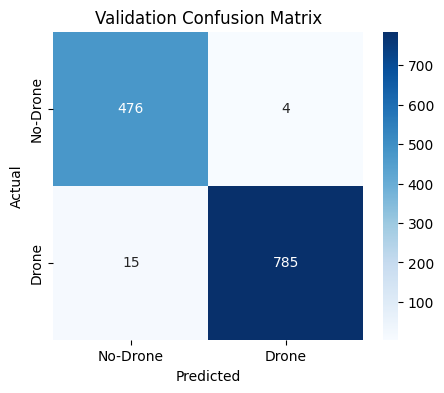

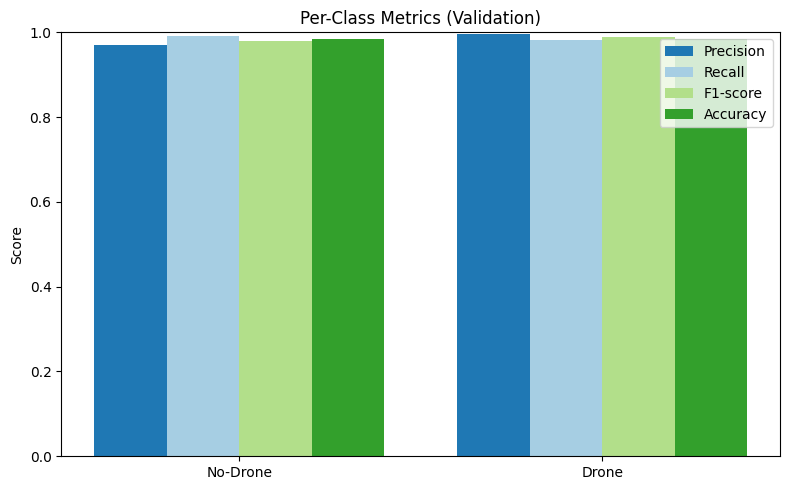


===== Validation Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.9695    0.9917    0.9804       480
       Drone     0.9949    0.9812    0.9880       800

    accuracy                         0.9852      1280
   macro avg     0.9822    0.9865    0.9842      1280
weighted avg     0.9854    0.9852    0.9852      1280



In [ ]:
val_results   = test_unimodal(trained_model, loaders['val'], DEVICE, modal_num=modal_num, dataset_name="Validation")
# Validation
plot_confusion_matrix(val_results['y_true'], val_results['y_pred'], title="Validation Confusion Matrix")
plot_per_class_metrics_group(val_results['y_true'], val_results['y_pred'], dataset_name="Validation")
print_classification_report(val_results['y_true'], val_results['y_pred'], dataset_name="Validation")

Testing Test: 100%|██████████| 42/42 [00:03<00:00, 11.23it/s]


===== Test Results =====
Accuracy: 0.9848 | F1 (macro): 0.9837
Latency: 0.58 ms/sample | FPS: 1715.51



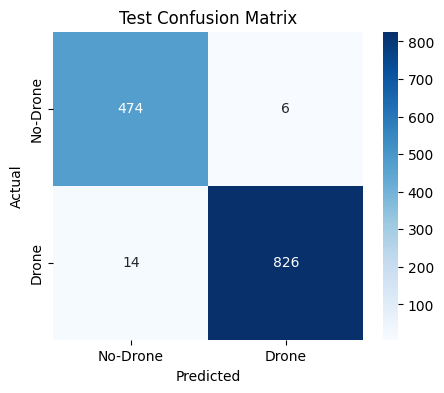

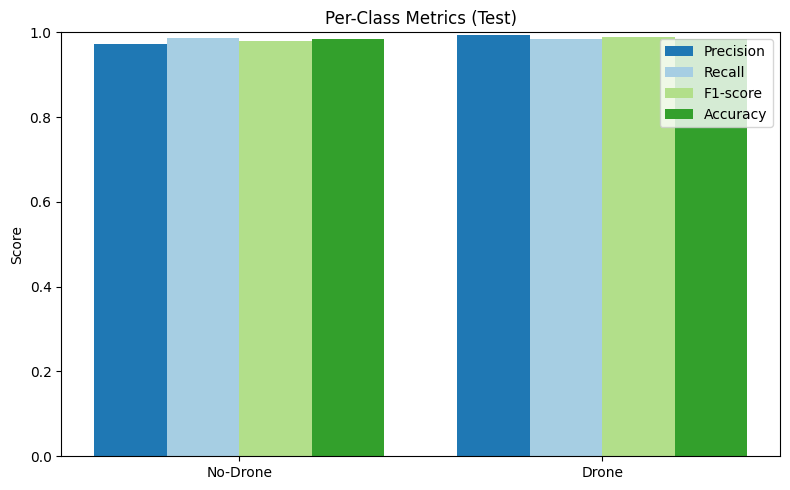


===== Test Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.9713    0.9875    0.9793       480
       Drone     0.9928    0.9833    0.9880       840

    accuracy                         0.9848      1320
   macro avg     0.9820    0.9854    0.9837      1320
weighted avg     0.9850    0.9848    0.9849      1320



In [ ]:
test_results  = test_unimodal(trained_model, loaders['test'], DEVICE, modal_num=modal_num, dataset_name="Test")
# Test
plot_confusion_matrix(test_results['y_true'], test_results['y_pred'], title="Test Confusion Matrix")
plot_per_class_metrics_group(test_results['y_true'], test_results['y_pred'], dataset_name="Test")
print_classification_report(test_results['y_true'], test_results['y_pred'], dataset_name="Test")